
# Problem 2

### Part C: TD(0)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error

# Given parameters from Problem 2

State_names = np.array(["A", "B", "C", "D", "E", "F", "G"])

A = 0
B = 1
C = 2
D = 3
E = 4
F = 5
G = 6

Start_state = D
Terminal_state = {A, G}
Normal_states = np.array([B, C, D, E, F])

gamma = 1
True_val = np.array([1/6, 2/6, 3/6, 4/6, 5/6])

In [ ]:
# Small helper functions

def random_walk_step(state):
    # left and right with equal probability
    action = np.random.choice([-1, 1]) # -1: left, 1: right
    next_state = state + action

    # Reward is 1 only when the transition -> G
    if next_state == G:
        reward = 1
    else:
        reward = 0

    return next_state, reward

def init_val():
    V = np.zeros(7)
    V[Normal_states] = 0.5 # initialize to 0.5
    return V

In [ ]:
def td0_predict(episodes = 100, alpha = 0.1):
    V = init_val()

    rms_history = np.zeros(episodes + 1)
    rms_history[0] = root_mean_squared_error(True_val, V[Normal_states])

    for ep in range(episodes):
        state = Start_state
        done = False

        while not done:
            next_state, reward = random_walk_step(state) # random walk -> get either left or right to next state

            # Update V -> formula from slides
            td_target = reward + gamma * V[next_state]
            td_error = td_target - V[state]
            V[state] += alpha * td_error

            state = next_state
            done = state in Terminal_state # terminate when reach G

        rms_history[ep + 1] = root_mean_squared_error(True_val, V[Normal_states]) # record rms error

    return V, rms_history

In [ ]:
def generate_episode():
    state = Start_state
    episode = []
    done = False

    while not done:
        next_state, reward = random_walk_step(state) # random walk
        episode.append((state, reward, next_state))

        state = next_state
        done = state in Terminal_state

    return episode

def mc_predict(episodes = 100, alpha = 0.01, first_visit = True):
    V = init_val()

    rms_history = np.zeros(episodes + 1)
    rms_history[0] = root_mean_squared_error(True_val, V[Normal_states])

    for ep in range(episodes):
        episode = generate_episode()

        # Compute the returns backward, find G_t
        G_return = 0
        returns = []

        for state, reward, _ in reversed(episode):
            G_return = reward + gamma * G_return
            returns.append((state, G_return))

        returns.reverse()

        # First-visit MC
        visited = set()
        for state, G_t in returns:
            if first_visit and state in visited:
                continue

            visited.add(state)
            V[state] += alpha * (G_t - V[state])

        rms_history[ep + 1] = root_mean_squared_error(True_val, V[Normal_states]) # this also avg over the 5 non-terminal states

    return V, rms_history

In [ ]:
# Run TD(0) and constant-alpha MC for 100 episodes
V_td, td_rms = td0_predict(episodes = 100, alpha = 0.1)
V_mc, mc_rms = mc_predict(episodes = 100, alpha = 0.01, first_visit=True)

# Print true values and estimated values
# Also print RMS error between estimated and true values, averaged over B, C, D, E, F
"""
print("True values for states B-F:")
for name, value in zip(State_names[Normal_states], True_val):
    print(f"{name}: {value:.3f}")
 """

print("\nTD(0) estimated values after 100 episodes:")
for state in Normal_states:
    print(f"{State_names[state]}: {V_td[state]:.3f}")
print(f"TD(0) RMS error: {td_rms[-1]:.4f}")

print("\nMC estimated values after 100 episodes:")
for state in Normal_states:
    print(f"{State_names[state]}: {V_mc[state]:.3f}")
print(f"MC RMS error: {mc_rms[-1]:.4f}")


TD(0) estimated values after 100 episodes:
B: 0.074
C: 0.190
D: 0.332
E: 0.611
F: 0.860
TD(0) RMS error: 0.1106

MC estimated values after 100 episodes:
B: 0.352
C: 0.410
D: 0.486
E: 0.578
F: 0.647
MC RMS error: 0.1287


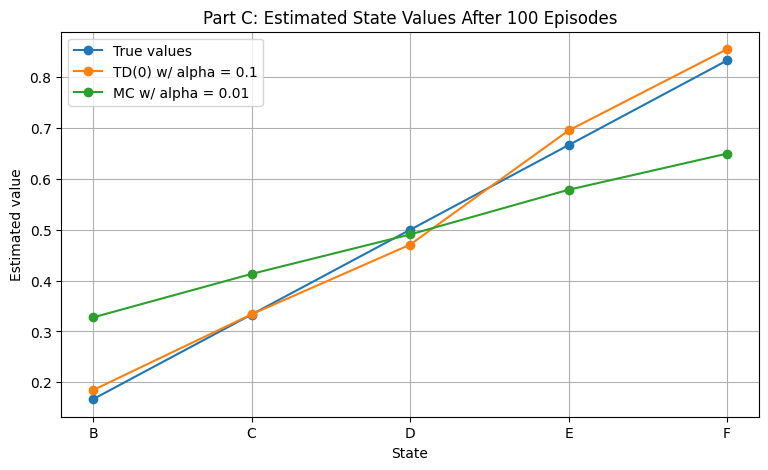

In [ ]:
# Plot estimated state values after 100 episodes
# Extra visualization for part C
plt.figure(figsize = (9, 5))

plt.plot(State_names[Normal_states], True_val, marker="o", label="True values")
plt.plot(State_names[Normal_states], V_td[Normal_states], marker="o", label="TD(0) w/ alpha = 0.1")
plt.plot(State_names[Normal_states], V_mc[Normal_states], marker="o", label="MC w/ alpha = 0.01")

plt.xlabel("State")
plt.ylabel("Estimated value")
plt.title("Part C: Estimated State Values After 100 Episodes")
plt.legend()
plt.grid(True)
plt.show()


### Part D: Plot RMS error vs episodes for both methods

In [ ]:
def average_rms_errors(method, alphas, runs, episodes):
    avg_results = {}

    for alpha in alphas:
        all_errors = []

        for iter in range(runs):
            if method == "td":
                _ , errors = td0_predict(episodes=episodes, alpha=alpha)
            elif method == "mc":
                _ , errors = mc_predict(episodes=episodes, alpha=alpha, first_visit = True)

            all_errors.append(errors)

        avg_results[alpha] = np.mean(all_errors, axis=0)

    return avg_results

# Given alphas for each method
TD_alphas = [0.05, 0.10, 0.15]
MC_alphas = [0.01, 0.02, 0.04]

# get averaged RMS errors -> 50 independent runs
td_avg = average_rms_errors("td", TD_alphas, runs = 50, episodes = 100)
mc_avg = average_rms_errors("mc", MC_alphas, runs = 50, episodes = 100)

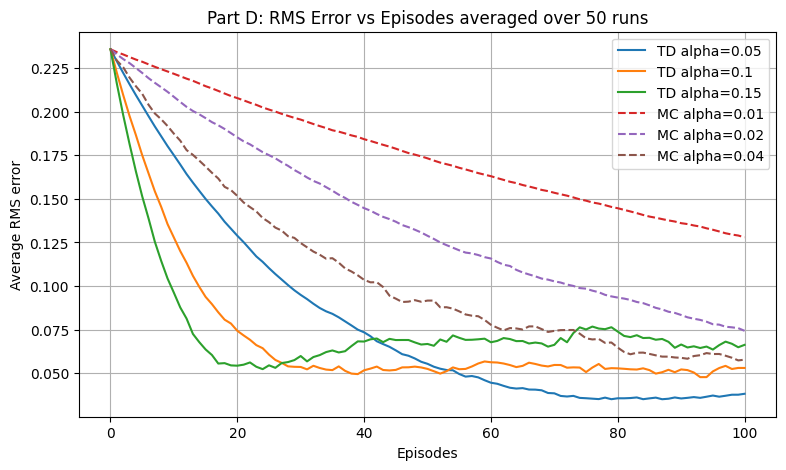

Average RMS errors after 100 episodes:
TD alpha = 0.05 -> 0.0383
TD alpha = 0.1 -> 0.0531
TD alpha = 0.15 -> 0.0663
MC alpha = 0.01 -> 0.1279
MC alpha = 0.02 -> 0.0744
MC alpha = 0.04 -> 0.0578


In [13]:
# Plot averaged RMS errors
plt.figure(figsize=(9, 5))

x = np.arange(101)

for a in TD_alphas:
    plt.plot(x, td_avg[a], label=f"TD alpha={a}")

for a in MC_alphas:
    plt.plot(x, mc_avg[a], linestyle="--", label=f"MC alpha={a}")

plt.xlabel("Episodes")
plt.ylabel("Average RMS error")
plt.title("Part D: RMS Error vs Episodes averaged over 50 runs")
plt.legend()
plt.grid(True)
plt.show()

# Print 
print("Average RMS errors after 100 episodes:")
for alpha in TD_alphas:
    print(f"TD alpha = {alpha} -> {td_avg[alpha][-1]:.4f}")
for alpha in MC_alphas:
    print(f"MC alpha = {alpha} -> {mc_avg[alpha][-1]:.4f}")


### RMSE plot discussion

As seen the in plot, RMS error decreases as more episodes are completed for both TD and MC. The rate of decrease varys for each method - in general, TD converges faster compared to MC for all alpha value tested. After the 100 episode is completed - TD is shown to be both faster and more accurate than MC for the specific learning rate (alpha value) chosen. For the TD method, higher learning rate alpha means faster decrease in error however, lower learning rate is slower but it does reach a lower RMS error in the end of the 100 episode run. MC with alpha 0.04 does reach the same general RMS level as the TD methods so it seems that learning rate can indeed effect the results quite a bit. TD methods still remains superior compared to MC methods for most learning rate tested, with TD (a=0.05) having the lowest RMS error recorded in any test here.